# 04 — Does the student need TALAS-style intermediate guidance?

Optional Appendix Figure A3. This notebook trains/reuses exactly two methods —
endpoint+(H_0) and TALAS — then compares teacher-layer × student-layer CKA on
one fixed held-out probe. Keep the figure only if its pattern is stable across
seeds and model pairs; it is descriptive, not causal evidence.

In [1]:
# 1. Settings
from pathlib import Path

REPO_URL = "https://github.com/duncan-nguyen/embedding-kd.git"
AUTO_PULL_REPO, INSTALL_REQUIREMENTS = True, True
PAIR = "qwen3_0.6b_to_minilm_h384"
TRAIN_DATA_REL = Path("data/train_set/train_100k.csv")
RUN_NAME = f"analysis_talas_cka_{PAIR}_v2"
SEEDS = [42]
BATCH_SIZE, EPOCHS = 128, 5
LRS = {"ours": 7e-5, "talas": 2e-5}
LAMBDA_H0 = 0.75
PROBE_SIZE, ENCODE_BATCH = 512, 64
DEVICE = "cuda"
EXECUTE, STOP_ON_ERROR, RENDER_FIGURE = True, True, True
CUDA_VISIBLE_DEVICES = "0"

In [2]:
# 2. Repo, dependencies, GPU và dữ liệu
import subprocess, sys

cwd = Path.cwd().resolve()
PROJECT_DIR = next((p for p in (cwd, cwd.parent) if (p / "main.py").is_file()), None)
if PROJECT_DIR is None:
    clone_parent = Path("/content") if Path("/content").is_dir() else cwd
    PROJECT_DIR = clone_parent / "embedding-kd"
    if not PROJECT_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)
    assert (PROJECT_DIR / "main.py").is_file(), f"Repo không hợp lệ: {PROJECT_DIR}"

tracked = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "status", "--porcelain", "--untracked-files=no"],
    check=True, capture_output=True, text=True,
).stdout.strip()
if AUTO_PULL_REPO and not tracked:
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=True)
elif AUTO_PULL_REPO:
    print("[git] Bỏ qua pull vì repo có tracked changes.")
if INSTALL_REQUIREMENTS:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(PROJECT_DIR / "requirements.txt")],
        check=True,
    )

git_head = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()
sys.path[:0] = [str(PROJECT_DIR), str(PROJECT_DIR / "notebooks")]
TRAIN_DATA = PROJECT_DIR / TRAIN_DATA_REL
assert TRAIN_DATA.is_file(), f"Thiếu training data: {TRAIN_DATA}"
if EXECUTE:
    import torch
    assert torch.cuda.is_available(), "Hãy bật GPU runtime trước khi train."
print(f"Repo: {PROJECT_DIR} @ {git_head}")
print(f"Training data: {TRAIN_DATA}")

Repo: /content/embedding-kd @ 9d111df
Training data: /content/embedding-kd/data/train_set/train_100k.csv


In [3]:
# 3. Plan: ours versus TALAS under the same corpus and seed set
import shlex
from _analysis_common import PAIRS, distill_command, run_jobs

pair, cache_dir = PAIRS[PAIR], PROJECT_DIR / "runs" / "teacher_cache"
run_root = PROJECT_DIR / "runs" / RUN_NAME
run_root.mkdir(parents=True, exist_ok=True)
jobs = []
for arm, method in (("ours", "geoode"), ("talas", "talas")):
    for seed in SEEDS:
        run_dir = run_root / arm / f"seed_{seed}"
        extra = ["--no_eval_retrieval"]
        if arm == "ours":
            extra += ["--projection_type", "pca", "--gauge_align", "--gauge_rotation", "procrustes",
                      "--gauge_refit_every", 1, "--lambda_end", 1, "--lambda_ctr", 0,
                      "--lambda_topo", LAMBDA_H0, "--lambda_h1", 0,
                      "--topo_teacher_source", "original"]
        jobs.append({
            "name": f"{arm}/seed_{seed}", "arm": arm, "seed": seed, "run_dir": run_dir,
            "command": distill_command(
                PROJECT_DIR, method=method, pair=pair, train_data=TRAIN_DATA,
                cache_dir=cache_dir, run_dir=run_dir, seed=seed,
                batch_size=BATCH_SIZE, epochs=EPOCHS, learning_rate=LRS[arm], extra=extra,
            ),
        })
print(f"Plan: {len(jobs)} jobs -> {run_root}")
for job in jobs:
    print(shlex.join(job["command"]))

Plan: 2 jobs -> /content/embedding-kd/runs/analysis_talas_cka_qwen3_0.6b_to_minilm_h384_v2
/usr/bin/python3 /content/embedding-kd/main.py --method geoode --train_data /content/embedding-kd/data/train_set/train_100k.csv --student_model nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base --teacher_model Qwen/Qwen3-Embedding-0.6B --teacher_pooling last_token --batch_size 128 --epochs 5 --save_every 5 --lr 7e-05 --max_length 256 --seed 42 --num_workers 2 --eval_every 0 --pair_threshold_source test --cache_dir /content/embedding-kd/runs/teacher_cache --save_dir /content/embedding-kd/runs/analysis_talas_cka_qwen3_0.6b_to_minilm_h384_v2/ours/seed_42 --no_wandb --student_pooling cls --no_eval_retrieval --projection_type pca --gauge_align --gauge_rotation procrustes --gauge_refit_every 1 --lambda_end 1 --lambda_ctr 0 --lambda_topo 0.75 --lambda_h1 0 --topo_teacher_source original
/usr/bin/python3 /content/embedding-kd/main.py --method talas --train_data /content/embedding-kd/data/train_set/train

In [4]:
# 4. Chạy tuần tự; final-test record là resume boundary
from IPython.display import display

if EXECUTE:
    display(run_jobs(
        PROJECT_DIR, jobs, cuda_visible_devices=CUDA_VISIBLE_DEVICES,
        stop_on_error=STOP_ON_ERROR,
    ))
else:
    print("Dry run: đặt EXECUTE=True để chạy các job còn thiếu.")

[RUN 1/2] ours/seed_42 -> /content/embedding-kd/runs/analysis_talas_cka_qwen3_0.6b_to_minilm_h384_v2/ours/seed_42

Configuration for GEOODE method:
  task_type                 : pair_cls
  max_length                : 256
  batch_size                : 128
  epochs                    : 5
  learning_rate             : 7e-05
  min_lr                    : 2e-06
  warmup_ratio              : 0.06
  w_task                    : 0.5
  alpha_dtw                 : 0.5
  w_cls                     : 1.0
  temperature               : 0.07
  student_model_name        : nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
  teacher_model_name        : Qwen/Qwen3-Embedding-0.6B
  teacher_dtype             : bfloat16
  pooling_method            : last_token
  student_special_token     : ##
  teacher_special_token     : G
  train_data_path           : /content/embedding-kd/data/train_set/train_100k.csv
  cache_dir                 : /content/embedding-kd/runs/teacher_cache
  cache_batch_size          : 128


,name,arm,seed,run_dir,status,seconds
0,ours/seed_42,ours,42,/content/embedding-kd/runs/analysis_talas_cka_...,complete,260.947541
1,talas/seed_42,talas,42,/content/embedding-kd/runs/analysis_talas_cka_...,complete,657.762574


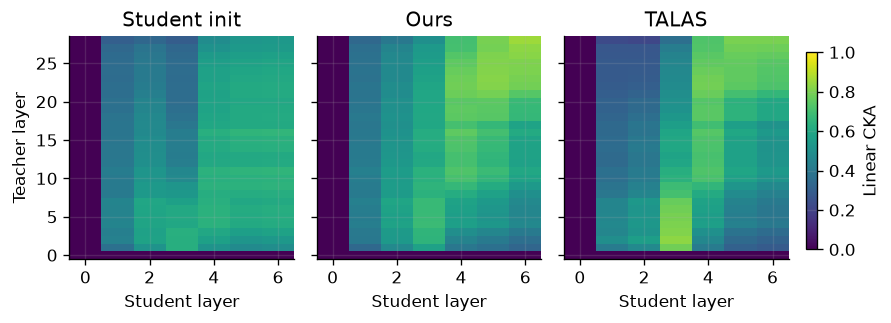

In [7]:
# 5. Optional Appendix Figure A3 — layerwise CKA
missing = [run_root / arm / f"seed_{seed}" / f"checkpoint_epoch_{EPOCHS}.pt"
           for arm in ("ours", "talas") for seed in SEEDS
           if not (run_root / arm / f"seed_{seed}" / f"checkpoint_epoch_{EPOCHS}.pt").is_file()]
if RENDER_FIGURE and missing:
    print(f"Missing {len(missing)} checkpoints; run the grid before rendering CKA.")
elif RENDER_FIGURE:
    import gc
    import numpy as np
    import pandas as pd
    import torch
    import matplotlib.pyplot as plt
    from transformers import AutoTokenizer
    from _analysis_common import set_paper_style
    from src import structural_audit as audit

    checkpoints = {
        arm: {seed: run_root / arm / f"seed_{seed}" / f"checkpoint_epoch_{EPOCHS}.pt" for seed in SEEDS}
        for arm in ("ours", "talas")
    }
    frame = pd.read_csv(TRAIN_DATA)
    text_col = "text" if "text" in frame else "premise"
    unique = frame[text_col].astype(str).drop_duplicates()
    texts = unique.sample(n=min(PROBE_SIZE, len(unique)), random_state=0).tolist()
    out_dir = run_root / "layerwise_cka"
    out_dir.mkdir(parents=True, exist_ok=True)

    def encode(label, model_name, checkpoint, pooling):
        path = out_dir / f"{label}.pt"
        if path.is_file():
            return torch.load(path, map_location="cpu", weights_only=False)
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = audit.load_student(model_name, checkpoint, device=DEVICE)
        layers = audit.encode_texts(model, tokenizer, texts, device=DEVICE, pooling=pooling,
                                    batch_size=ENCODE_BATCH, layers=True, progress=True)["layers"]
        torch.save(layers, path)
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return layers

    teacher = encode("teacher", pair["teacher"], None, pair["teacher_pooling"])
    student_init = encode("student_init", pair["student"], None, pair["student_pooling"])
    init_matrix = np.asarray([[audit.linear_cka(t, s) for s in student_init] for t in teacher])
    pd.DataFrame(init_matrix).to_csv(out_dir / "cka_student_init.csv", index=False)
    matrices = {"Student init": init_matrix}
    for arm, label in (("ours", r"Ours"), ("talas", "TALAS")):
        per_seed = []
        for seed in SEEDS:
            student = encode(f"{arm}_seed_{seed}", pair["student"], checkpoints[arm][seed],
                             pair["student_pooling"])
            matrix = np.asarray([[audit.linear_cka(t, s) for s in student] for t in teacher])
            pd.DataFrame(matrix).to_csv(out_dir / f"cka_{arm}_seed_{seed}.csv", index=False)
            per_seed.append(matrix)
        matrices[label] = np.mean(np.stack(per_seed), axis=0)

    set_paper_style()
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.65), sharex=True, sharey=True)
    for ax, (label, matrix) in zip(axes, matrices.items()):
        image = ax.imshow(matrix, origin="lower", aspect="auto", cmap="viridis",
                          vmin=0, vmax=1, rasterized=True)
        ax.set(title=label, xlabel="Student layer")
    axes[0].set_ylabel("Teacher layer")
    fig.subplots_adjust(left=.07, right=.88, bottom=.18, top=.88, wspace=.10)
    color_ax = fig.add_axes([.90, .21, .012, .62])
    fig.colorbar(image, cax=color_ax, label="Linear CKA")
    fig.savefig(out_dir / "figure_A3_optional_talas_cka.pdf", bbox_inches="tight")
    fig.savefig(out_dir / "figure_A3_optional_talas_cka.png", dpi=300, bbox_inches="tight")
    plt.show()